## Importing the Libraries

In [22]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
np.random.seed(42)
import matplotlib.pyplot as plt

## Reading Csv File

In [23]:
df = pd.read_csv("./Datasets/tvmarketing.csv")
df.head()

,TV,Sales
0,230.1,22.1
1,44.5,10.4
2,17.2,9.3
3,151.5,18.5
4,180.8,12.9


## Linear Regression

In [24]:
X = df["TV"].to_numpy()
Y = df["Sales"]
# Normalizing the Data

X_norm = (X - np.mean(X))/(np.std(X))
Y_norm = (Y - np.mean(Y))/(np.std(Y))
print(X_norm.shape)
print(Y_norm.shape)



(200,)
(200,)


## Loss Function

A **loss function** measures how far the model's predicted values are from the actual values.

For Linear Regression, we use the **Mean Squared Error (MSE)** based cost function:

$$
J(W,b) = \frac{1}{2n}\sum_{i=1}^{n}(y_i-\hat{y}_i)^2
$$

Where:

- $n$ = number of training samples
- $y_i$ = actual value
- $\hat{y}_i$ = predicted value
- $W$ = weights
- $b$ = bias

For Multiple Linear Regression:

$$
\hat{Y} = XW + b
$$

Therefore, the loss can be written as:

$$
J(W,b) = \frac{1}{2n}\sum_{i=1}^{n}(Y_i-\hat{Y}_i)^2
$$

### Why Square the Error?

Squaring the residuals:

- Prevents positive and negative errors from cancelling each other.
- Penalizes larger errors more strongly.
- Makes the loss differentiable, which is useful for Gradient Descent.

### Why use $\frac{1}{2n}$?

The factor $\frac{1}{n}$ takes the average error over all training samples.

The extra $\frac{1}{2}$ is used for mathematical convenience because when differentiating the squared error, the `2` produced by the derivative cancels with this $\frac{1}{2}$.




In [25]:
def loss_func(Y, Y_hat):
    return (1/(2*len(Y)))*np.sum((Y - Y_hat)**2)


## Gradient Descent

**Gradient Descent** is an optimization algorithm used to minimize the loss function by continuously updating the model parameters.

In Linear Regression, our goal is to find the optimal values of:

- $W$ = weights
- $b$ = bias

that minimize the cost function:

$$
J(W,b) = \frac{1}{2n}\sum_{i=1}^{n}(y_i-\hat{y}_i)^2
$$

### Basic Idea

Gradient Descent calculates the derivative (gradient) of the loss function with respect to each parameter.

The gradient tells us the direction in which the loss increases.

Therefore, to minimize the loss, we move in the **opposite direction of the gradient**.

### Weight Update

$$
W := W - \alpha \frac{\partial J}{\partial W}
$$

### Bias Update

$$
b := b - \alpha \frac{\partial J}{\partial b}
$$

Where:

- $\alpha$ = learning rate
- $\frac{\partial J}{\partial W}$ = gradient of loss with respect to weights
- $\frac{\partial J}{\partial b}$ = gradient of loss with respect to bias




In [26]:
def dEdm(x,Y, Y_hat):
    return 1/len(Y)*np.dot(Y_hat - Y,x)

def dEdb(Y, Y_hat):
    return 1/len(Y)*np.sum(Y_hat - Y)

### Training Function

In [27]:
def train(x,Y,m,b,learning_rate = 0.01,num_iter = 1000):
    for i in range(num_iter):
        Y_hat = m*x +b
        m = m - learning_rate * dEdm(x, Y, Y_hat)
        b = b - learning_rate * dEdb(Y, Y_hat)

        Y_hat = m*x +b
        loss = loss_func(Y,Y_hat)

        print(f"Loss in iteration {i} : {loss}")
    return m,b



In [28]:
m = 0 ; b =0
m,b = train(X_norm,Y_norm,m,b)
print(f"m = {m}, b = {b}")

Loss in iteration 0 : 0.4939118432440418
Loss in iteration 1 : 0.4879448408075272
Loss in iteration 2 : 0.48209658171949926
Loss in iteration 3 : 0.4763647029873229
Loss in iteration 4 : 0.470746888641917
Loss in iteration 5 : 0.4652408688019847
Loss in iteration 6 : 0.45984441875686694
Loss in iteration 7 : 0.4545553580676471
Loss in iteration 8 : 0.4493715496861427
Loss in iteration 9 : 0.44429089909143027
Loss in iteration 10 : 0.43931135344355254
Loss in iteration 11 : 0.4344309007540677
Loss in iteration 12 : 0.42964756907310353
Loss in iteration 13 : 0.4249594256925906
Loss in iteration 14 : 0.4203645763653498
Loss in iteration 15 : 0.4158611645397211
Loss in iteration 16 : 0.4114473706094225
Loss in iteration 17 : 0.40712141117833667
Loss in iteration 18 : 0.4028815383399297
Loss in iteration 19 : 0.39872603897100684
Loss in iteration 20 : 0.3946532340395257
Loss in iteration 21 : 0.39066147792618083
Loss in iteration 22 : 0.3867491577594917
Loss in iteration 23 : 0.382914692764

### Predict Function

In [29]:
def predict(m,b,X):
    return m*X + b

In [30]:
Y_hat = predict(m,b,X_norm)
loss = loss_func(Y_norm,Y_hat)
loss

np.float64(0.19406247514515756)

### Denormalization

After prediction, the output is still in the normalized scale.

To bring predictions back to their original units, we reverse the normalization:

$$
Y_{\text{original}} = Y_{\text{normalized}} \times \sigma_Y + \mu_Y
$$

In NumPy:

```python
Y_hat_original = Y_hat * np.std(Y) + np.mean(Y)
```

In [31]:

Y_pred_original = Y_hat * np.std(Y) + np.mean(Y)

In [32]:
df = pd.DataFrame({
    "Actual" : Y,
    "Predicted" : Y_pred_original,
    "Residual": Y - Y_pred_original
}
 )

In [33]:
df.head(10)

,Actual,Predicted,Residual
0,22.1,17.970604,4.129396
1,10.4,9.148184,1.251816
2,9.3,7.850490,1.449510
3,18.5,14.234385,4.265615
4,12.9,15.627149,-2.727149
5,7.2,7.446446,-0.246446
6,11.8,9.766134,2.033866
7,13.2,12.746553,0.453447
8,4.8,7.441693,-2.641693
9,10.6,16.530306,-5.930306


### plotting out line

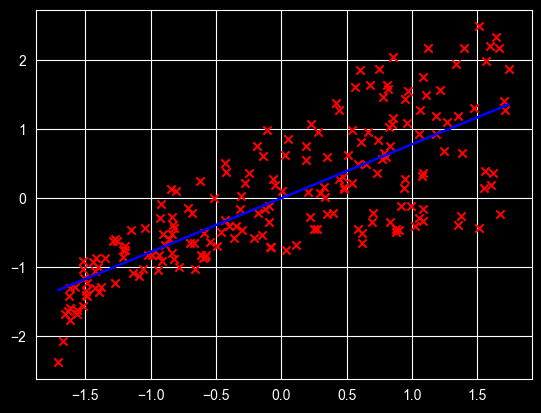

In [34]:
plt.scatter(X_norm,Y_norm, marker="x", c="r")
plt.plot(X_norm,Y_hat, c="b")

### Comparison with Sklearn

In [36]:
## it require 2d array
X_sklearn = X_norm.reshape(-1, 1)

model = LinearRegression()
model.fit(X_sklearn, Y_norm)
print("m:",m)
print("b:", b)
print("Sklearn m:", model.coef_[0])
print("Sklearn b:", model.intercept_)

m: 0.7821906552574298
b: -2.77422529393339e-16
Sklearn m: 0.7822244248616067
Sklearn b: -2.642826921026317e-16
